In [10]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

I0000 00:00:1775209887.520515    1924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775209888.054185    1924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775209890.017144    1924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [11]:
import kagglehub

path = kagglehub.dataset_download("bakhtiyar2222/deep-sar-oil-spill-segmentation-refined")

print("Path to dataset files:", path)

Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1


In [12]:
IMG_SIZE = 256

def load_data(image_dir, mask_dir):
    images, masks = [], []
    for fname in sorted(os.listdir(image_dir)):
        img  = cv2.imdecode(np.fromfile(os.path.join(image_dir, fname), dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imdecode(np.fromfile(os.path.join(mask_dir,  fname), dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None: continue
        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = (cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32)
        images.append(img[..., np.newaxis])
        masks.append(mask[..., np.newaxis])
    return np.array(images), np.array(masks)

In [13]:
base = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1"

X, Y = load_data(
    image_dir = base + "/images/images/train",
    mask_dir  = base + "/masks/masks/train"
)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Unique mask values: {np.unique(Y_train)}")  

Train: (5164, 256, 256, 1), Test: (1291, 256, 256, 1)
Unique mask values: [0. 1.]


In [15]:
def unet():
    inp = layers.Input((256, 256, 1))
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inp);  p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1);   p2 = layers.MaxPooling2D()(c2)
    bn = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)
    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(bn);  u1 = layers.Concatenate()([u1, c2]); u1 = layers.Conv2D(32, 3, activation="relu", padding="same")(u1)
    u2 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(u1);  u2 = layers.Concatenate()([u2, c1]); u2 = layers.Conv2D(16, 3, activation="relu", padding="same")(u2)
    out = layers.Conv2D(1, 1, activation="sigmoid")(u2)
    return Model(inp, out)

model = unet()
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train, Y_train, validation_split=0.2, epochs=20, batch_size=4)

W0000 00:00:1775203002.479025    1313 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 78s 73ms/step - accuracy: 0.8355 - loss: 0.3803 - val_accuracy: 0.8853 - val_loss: 0.3051
Epoch 2/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 76s 73ms/step - accuracy: 0.8848 - loss: 0.2973 - val_accuracy: 0.8953 - val_loss: 0.2732
Epoch 3/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.8908 - loss: 0.2809 - val_accuracy: 0.9006 - val_loss: 0.2596
Epoch 4/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 73s 71ms/step - accuracy: 0.8937 - loss: 0.2710 - val_accuracy: 0.9023 - val_loss: 0.2569
Epoch 5/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.8951 - loss: 0.2645 - val_accuracy: 0.9016 - val_loss: 0.2489
Epoch 6/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.8957 - loss: 0.2604 - val_accuracy: 0.9021 - val_loss: 0.2446
Epoch 7/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - accuracy: 0.8964 - loss: 0.2571 - val_accuracy: 0.9037 - val_loss: 0.2407
Epoch 8/20
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.8968 -

In [16]:
model.save("unet_oilspill.h5")
print("Model saved successfully!")

Model saved successfully!


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step
IoU: 0.5778
Dice: 0.6944


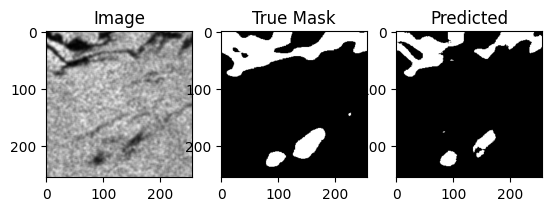

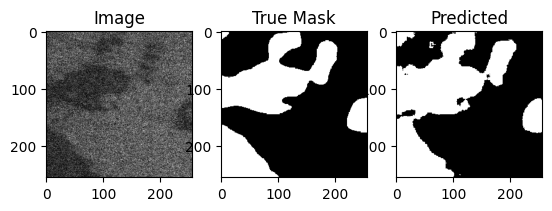

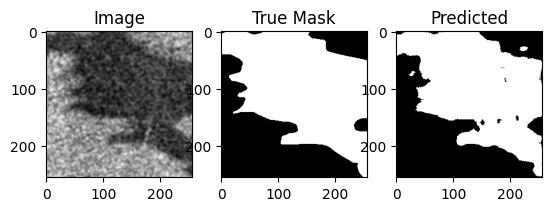

In [17]:
preds = model.predict(X_test)
iou  = lambda yt, yp: np.sum(yt * (yp>0.5)) / (np.sum(yt + (yp>0.5)) - np.sum(yt * (yp>0.5)) + 1e-6)
dice = lambda yt, yp: 2*np.sum(yt*(yp>0.5)) / (np.sum(yt) + np.sum(yp>0.5) + 1e-6)
print(f"IoU: {np.mean([iou(Y_test[i], preds[i]) for i in range(len(preds))]):.4f}")
print(f"Dice: {np.mean([dice(Y_test[i], preds[i]) for i in range(len(preds))]):.4f}")


for i in range(min(3, len(X_test))):
    plt.subplot(1,3,1); plt.imshow(X_test[i,:,:,0], cmap="gray");       plt.title("Image")
    plt.subplot(1,3,2); plt.imshow(Y_test[i,:,:,0], cmap="gray");       plt.title("True Mask")
    plt.subplot(1,3,3); plt.imshow(preds[i,:,:,0]>0.5, cmap="gray");   plt.title("Predicted")
    plt.show()

W0000 00:00:1775210150.101380    1924 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step


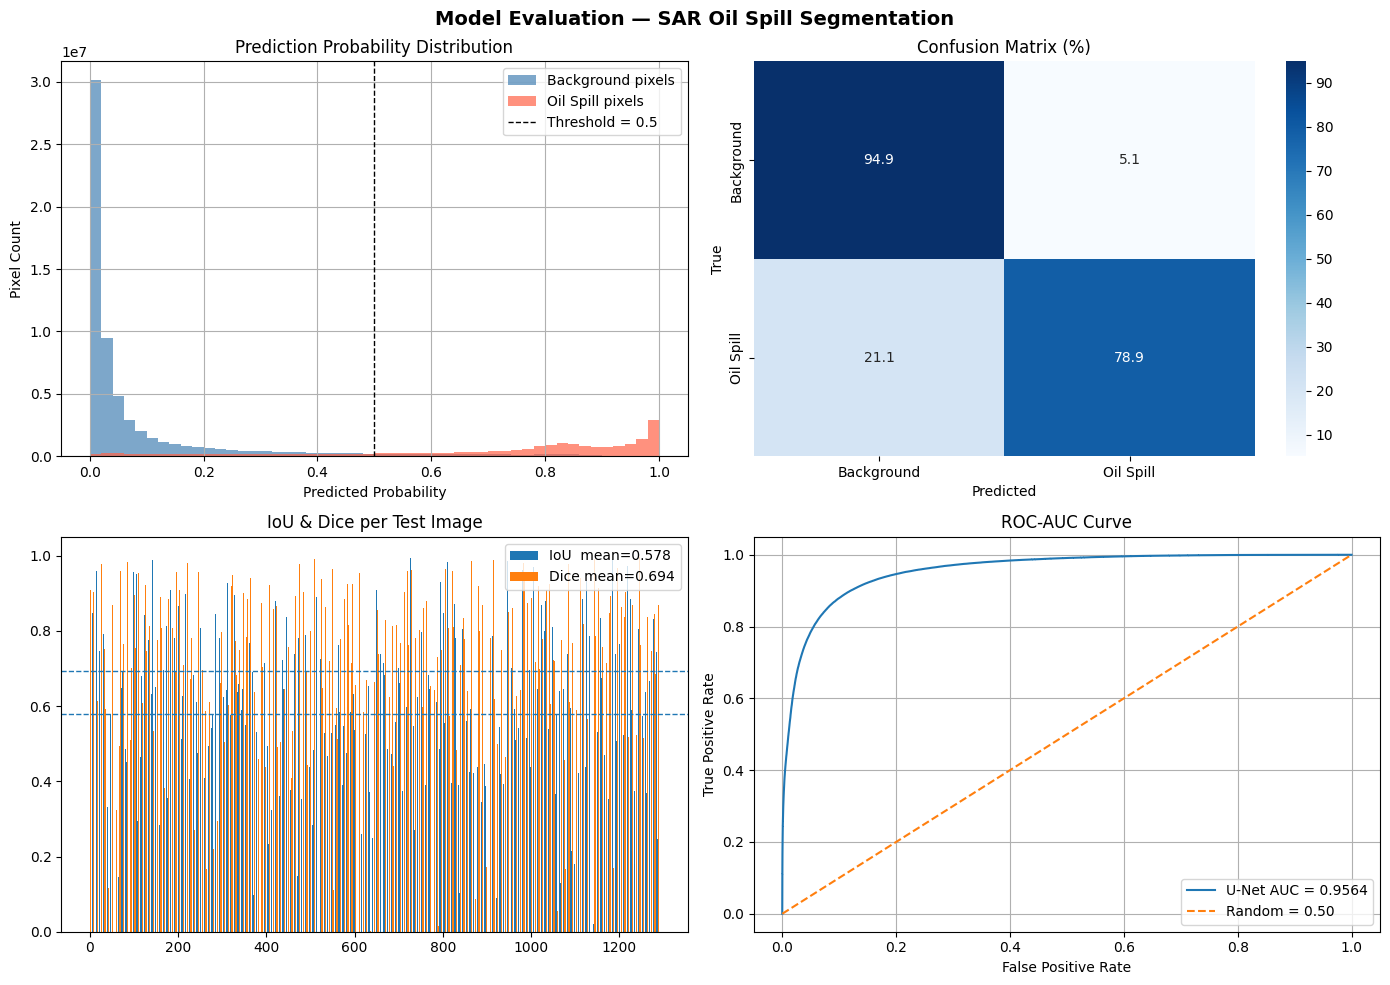

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model

model = load_model("unet_oilspill.h5", compile=False)


base = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1"

X, Y = load_data(base + "/images/images/train", base + "/masks/masks/train")
_, X_test, _, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

preds = model.predict(X_test)

yt = Y_test.flatten()
yp = preds.flatten()
yb = (yp > 0.5).astype(np.float32)

ious  = [np.sum(Y_test[i]*(preds[i]>0.5)) / (np.sum(Y_test[i]+(preds[i]>0.5)) - np.sum(Y_test[i]*(preds[i]>0.5)) + 1e-6) for i in range(len(preds))]
dices = [2*np.sum(Y_test[i]*(preds[i]>0.5)) / (np.sum(Y_test[i]) + np.sum(preds[i]>0.5) + 1e-6) for i in range(len(preds))]

idx = np.random.choice(len(yt), min(500_000, len(yt)), replace=False)
fpr, tpr, _ = roc_curve(yt[idx], yp[idx])
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Evaluation — SAR Oil Spill Segmentation", fontsize=14, fontweight="bold")

# Plot 1 — Prediction Probability Distribution
axes[0,0].hist(yp[yt==0], bins=50, alpha=0.7, color="steelblue", label="Background pixels")
axes[0,0].hist(yp[yt==1], bins=50, alpha=0.7, color="tomato",    label="Oil Spill pixels")
axes[0,0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="Threshold = 0.5")
axes[0,0].set_title("Prediction Probability Distribution")
axes[0,0].set_xlabel("Predicted Probability"); axes[0,0].set_ylabel("Pixel Count")
axes[0,0].legend(); axes[0,0].grid(True)

# Plot 2 — Confusion Matrix
cm = confusion_matrix(yt[idx], yb[idx])
sns.heatmap(cm / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt=".1f",
            xticklabels=["Background","Oil Spill"], yticklabels=["Background","Oil Spill"],
            cmap="Blues", ax=axes[0,1])
axes[0,1].set_title("Confusion Matrix (%)"); axes[0,1].set_xlabel("Predicted"); axes[0,1].set_ylabel("True")

# Plot 3 — IoU and Dice per test image
x = np.arange(len(ious))
axes[1,0].bar(x-0.2, ious,  width=0.35, label=f"IoU  mean={np.mean(ious):.3f}")
axes[1,0].bar(x+0.2, dices, width=0.35, label=f"Dice mean={np.mean(dices):.3f}")
axes[1,0].axhline(np.mean(ious),  linestyle="--", linewidth=1)
axes[1,0].axhline(np.mean(dices), linestyle="--", linewidth=1)
axes[1,0].set_title("IoU & Dice per Test Image"); axes[1,0].legend(); axes[1,0].set_ylim(0, 1.05)

# Plot 4 — ROC-AUC
axes[1,1].plot(fpr, tpr, label=f"U-Net AUC = {roc_auc:.4f}")
axes[1,1].plot([0,1], [0,1], linestyle="--", label="Random = 0.50")
axes[1,1].set_title("ROC-AUC Curve"); axes[1,1].set_xlabel("False Positive Rate")
axes[1,1].set_ylabel("True Positive Rate"); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150)
plt.show()

In [18]:
print("------")

------
